## Импорт библиотек

In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
import itertools
import ast  

In [44]:
df_train = pd.read_json("../data/train.json")
df_test = pd.read_json("../data/test.json")

In [45]:
# df_train.info()
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74659 entries, 0 to 124010
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        74659 non-null  float64
 1   bedrooms         74659 non-null  int64  
 2   building_id      74659 non-null  object 
 3   created          74659 non-null  object 
 4   description      74659 non-null  object 
 5   display_address  74659 non-null  object 
 6   features         74659 non-null  object 
 7   latitude         74659 non-null  float64
 8   listing_id       74659 non-null  int64  
 9   longitude        74659 non-null  float64
 10  manager_id       74659 non-null  object 
 11  photos           74659 non-null  object 
 12  price            74659 non-null  int64  
 13  street_address   74659 non-null  object 
dtypes: float64(3), int64(3), object(8)
memory usage: 8.5+ MB


In [46]:
df_train.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


In [47]:
df_train.corr(numeric_only=True)

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


In [48]:
cols_to_keep_train = ['bathrooms', 'bedrooms', 'interest_level', 'price', 'features']
cols_to_keep_test  = ['bathrooms', 'bedrooms', 'features', 'price']

df_train = df_train[cols_to_keep_train].copy()
df_test  = df_test[cols_to_keep_test].copy()

df_train.head()


q_low, q_high = df_train['price'].quantile([0.01, 0.99])

df_train = df_train[(df_train['price'] > q_low) & (df_train['price'] < q_high)]
df_test  = df_test[(df_test['price'] > q_low) & (df_test['price'] < q_high)]

Text(0.5, 1.0, 'Гистограмма распределения цен на жильё')

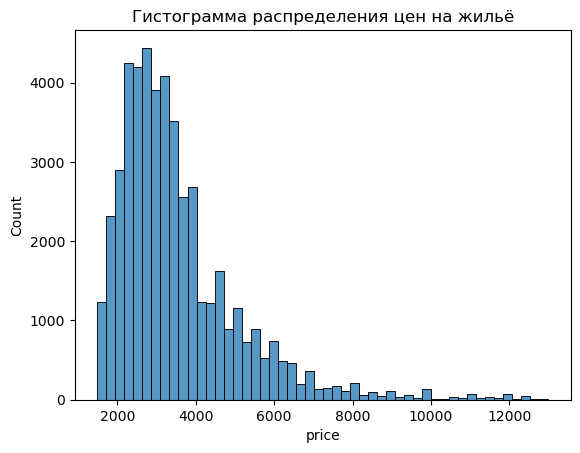

In [49]:
sns.histplot(data=df_train, x='price', bins=50)
plt.title('Гистограмма распределения цен на жильё')

## Анализ данных

In [50]:
empty_features_count = df_train['features'].apply(len).eq(0).sum()
print(f"Количество квартир с пустыми features: {empty_features_count}")

df_train = df_train[df_train['features'].apply(len) > 0].reset_index(drop=True)
df_train['features'] = df_train['features'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df_test['features']  = df_test['features'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)



Количество квартир с пустыми features: 3106


bathrooms = 1.5, 2.5, 3.5, 4.5, 6.5 такие значения могут встречаться в американской недвижимости.

Там считают «half-bathroom» (туалет без душа/ванны). 

Например:

    •       1.5 bathrooms = одна полноценная ванная + один туалет.
	•	2.5 bathrooms = две полные + один туалет.

In [51]:
df_train.loc[df_train['bathrooms'] > 4.0, 'bathrooms'] = df_train['bathrooms'].mean()
df_test.loc[df_test['bathrooms'] > 4.0, 'bathrooms'] = df_test['bathrooms'].mean()  #TODO: check if needed

#### Преобразование столбца `features` из строкового представления списка в настоящий список


In [52]:
all_features = list(itertools.chain.from_iterable(df_train['features']))
feature_counts = Counter(all_features)
top_20_features = [f for f, _ in feature_counts.most_common(20)]

for f in top_20_features:
    df_train[f] = df_train['features'].apply(lambda feats: int(f in feats))
    df_test[f]  = df_test['features'].apply(lambda feats: int(f in feats))

for f in top_20_features:
    if f not in df_test.columns:
        df_test[f] = 0

feature_cols = ['bathrooms', 'bedrooms'] + top_20_features
X_train = df_train[feature_cols].values
y_train = df_train['price'].values
X_test  = df_test[feature_cols].values
y_test  = df_test['price'].values

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (45237, 22) | Test: (73179, 22)


#### Визуализация топ-20 самых частых признаков

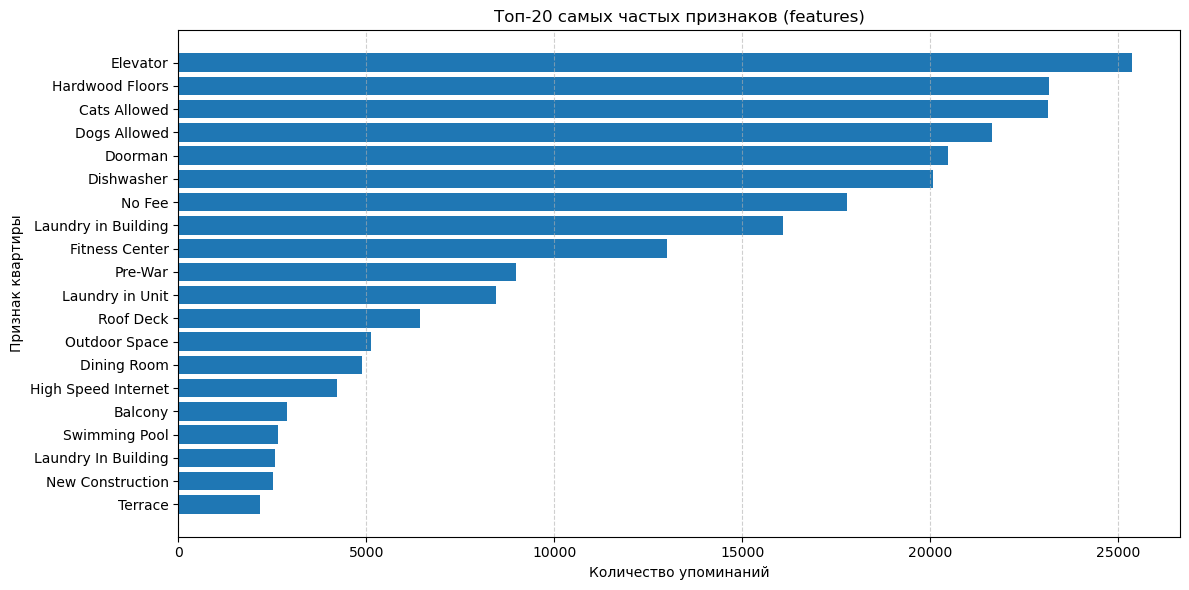

In [53]:
top_20_counts = feature_counts.most_common(20)

features_names = [f[0] for f in top_20_counts]
features_values = [f[1] for f in top_20_counts]

plt.figure(figsize=(12, 6))
plt.barh(features_names[::-1], features_values[::-1])
plt.title("Топ-20 самых частых признаков (features)")
plt.xlabel("Количество упоминаний")
plt.ylabel("Признак квартиры")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### Реализация с использованием нормального уравнения

In [54]:
class MyLinearRegressionAnalytical:
    def __init__(self):
        
        self.w = None

    def fit(self, X, y):

        X_with_bias = np.c_[np.ones(X.shape[0]), X]
        
        XTX = X_with_bias.T @ X_with_bias
        
        XTX_inv = np.linalg.pinv(XTX)
        
        XTy = X_with_bias.T @ y
        
        self.w = XTX_inv @ XTy
        
        return self

    def predict(self, X):

        if self.w is None:
            raise Exception("Модель еще не обучена. Вызовите метод fit() сначала.")
        
        X_with_bias = np.c_[np.ones(X.shape[0]), X]
        
        y_pred = X_with_bias @ self.w
        
        return y_pred

#### Метрики

In [55]:
def mse_gradient(X, w, y):
    y_pred = X @ w
    grad = (2 / len(X)) * X.T @ (y_pred - y)
    return grad

def mse(X, w, y):
    y_pred = X @ w
    return np.sum((y - y_pred) ** 2) / len(y_pred)

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

#### Реализация с использованием градиентного спуска

In [56]:
class MyLinearRegressionGD:
    def __init__(self, lr=1, n_epochs=1000, eps=1e-6, seed=21, verbose=True):
        self.lr = lr
        self.n_epochs = int(n_epochs)
        self.eps = float(eps)
        self.verbose = verbose
        self.seed = seed
        self.w = None
        self.rng = np.random.RandomState(seed) if seed is not None else np.random

    def _add_bias(self, X):
        X = np.asarray(X)
        return np.hstack([np.ones((X.shape[0], 1)), X])

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        Xb = self._add_bias(X)

        self.w = np.zeros(Xb.shape[1])
        next_w = self.w.copy()
        history = []

        for epoch in range(self.n_epochs):
            cur_w = next_w.copy()
            grad = mse_gradient(Xb, cur_w, y) # Batch Gradient Descent, градиент вычисляется по всем объектам сразу
            next_w = cur_w - self.lr * grad
            delta = np.linalg.norm(next_w - cur_w)
            loss = mse(Xb, cur_w, y)

            history.append((epoch + 1, loss, delta))
            if len(history) > 5:
                history.pop(0) 

            if self.verbose and epoch < 5:
                print(f"Итерация {epoch+1:5d}/{self.n_epochs}: MSE = {loss:12.6f}, Δw = {delta:.6e}")

            if delta <= self.eps:
                if self.verbose:
                    print(f"\nСходимость достигнута на итерации {epoch+1}: |Δw| = {delta:.2e} < eps = {self.eps}")
                    print("\nПоследние 5 итераций перед остановкой:")
                    for e, l, d in history:
                        print(f"Итерация {e:5d}/{self.n_epochs}: MSE = {l:12.6f}, Δw = {d:.6e}")
                break
        else:

            if self.verbose:
                print("\nПоследние 5 итераций:")
                for e, l, d in history:
                    print(f"Итерация {e:5d}/{self.n_epochs}: MSE = {l:12.6f}, Δw = {d:.6e}")

        self.w = next_w.copy()

        if self.verbose:
            print("\n Обучение завершено.")
            print(f"Финальная MSE: {mse(Xb, self.w, y):.6f}")
            print(f"Итераций выполнено: {epoch+1}")

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        Xb = self._add_bias(X)
        return Xb @ self.w
    


### Обучение модели

#### Подготовка данных

#### Вспомогательная функция добавления метрик в таблицу 

In [57]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])
result_R2 = pd.DataFrame(columns=['model', 'train', 'test'])


def add_result(model_name, y_train, y_train_pred, y_test, y_test_pred):
    mae_train = mae(y_train, y_train_pred)
    rmse_train = rmse(y_train, y_train_pred)
    r2_train = r2(y_train, y_train_pred)

    mae_test = mae(y_test, y_test_pred)
    rmse_test = rmse(y_test, y_test_pred)
    r2_test = r2(y_test, y_test_pred)

    result_MAE.loc[len(result_MAE)]  = [model_name, mae_train, mae_test]
    result_RMSE.loc[len(result_RMSE)] = [model_name, rmse_train, rmse_test]
    result_R2.loc[len(result_R2)]    = [model_name, r2_train, r2_test]

#### Обучение с использованием нормального уравнения

In [58]:
model_RA = MyLinearRegressionAnalytical()
model_RA.fit(X_train, y_train)

y_pred_train = model_RA.predict(X_train)
y_pred_test  = model_RA.predict(X_test)

add_result('LinReg Analytical', y_train, y_pred_train, y_test, y_pred_test)

print(f"Train:")
print(f"  MAE  = {mae(y_train, y_pred_train):.2f}")
print(f"  RMSE = {rmse(y_train, y_pred_train):.2f}")
print(f"  R²   = {r2(y_train, y_pred_train):.4f}\n")

print(f"Test:")
print(f"  MAE  = {mae(y_test, y_pred_test):.2f}")
print(f"  RMSE = {rmse(y_test, y_pred_test):.2f}")
print(f"  R²   = {r2(y_test, y_pred_test):.4f}")

Train:
  MAE  = 707.38
  RMSE = 1023.30
  R²   = 0.5910

Test:
  MAE  = 711.54
  RMSE = 1021.21
  R²   = 0.5788


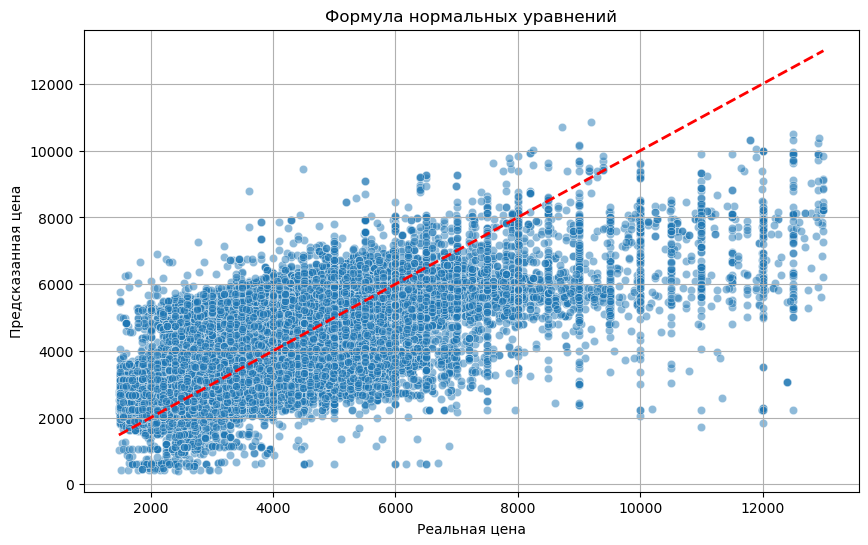

In [59]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red', lw=2)
plt.xlabel("Реальная цена")
plt.ylabel("Предсказанная цена")
plt.title("Формула нормальных уравнений")
plt.grid(True)
plt.show()

#### Обучение с использованием модели градиентного спуска

In [60]:
model_gd = MyLinearRegressionGD(lr=0.1, n_epochs=6000, eps=0.1, verbose=True)

model_gd.fit(X_train, y_train)

y_train_pred = model_gd.predict(X_train)
y_test_pred  = model_gd.predict(X_test)

add_result('LinReg GD', y_train, y_train_pred, y_test, y_test_pred)

print("\nМетрики для MyLinearRegressionGD:\n")
print(f"Train:")
print(f"  MAE  = {mae(y_train, y_train_pred):.2f}")
print(f"  RMSE = {rmse(y_train, y_train_pred):.2f}")
print(f"  R²   = {r2(y_train, y_train_pred):.4f}\n")

print(f"Test:")
print(f"  MAE  = {mae(y_test, y_test_pred):.2f}")
print(f"  RMSE = {rmse(y_test, y_test_pred):.2f}")
print(f"  R²   = {r2(y_test, y_test_pred):.4f}")

Итерация     1/6000: MSE = 15392404.694498, Δw = 2.069585e+03
Итерация     2/6000: MSE = 5571883.481343, Δw = 1.125349e+03
Итерация     3/6000: MSE = 2647115.989027, Δw = 6.132786e+02
Итерация     4/6000: MSE = 1759896.103330, Δw = 3.364218e+02
Итерация     5/6000: MSE = 1476549.305103, Δw = 1.880586e+02

Сходимость достигнута на итерации 579: |Δw| = 9.99e-02 < eps = 0.1

Последние 5 итераций перед остановкой:
Итерация   575/6000: MSE = 1047159.367952, Δw = 1.015309e-01
Итерация   576/6000: MSE = 1047159.265069, Δw = 1.011315e-01
Итерация   577/6000: MSE = 1047159.162994, Δw = 1.007339e-01
Итерация   578/6000: MSE = 1047159.061721, Δw = 1.003382e-01
Итерация   579/6000: MSE = 1047158.961241, Δw = 9.994445e-02

 Обучение завершено.
Финальная MSE: 1047158.861548
Итераций выполнено: 579

Метрики для MyLinearRegressionGD:

Train:
  MAE  = 707.37
  RMSE = 1023.31
  R²   = 0.5910

Test:
  MAE  = 711.52
  RMSE = 1021.21
  R²   = 0.5788


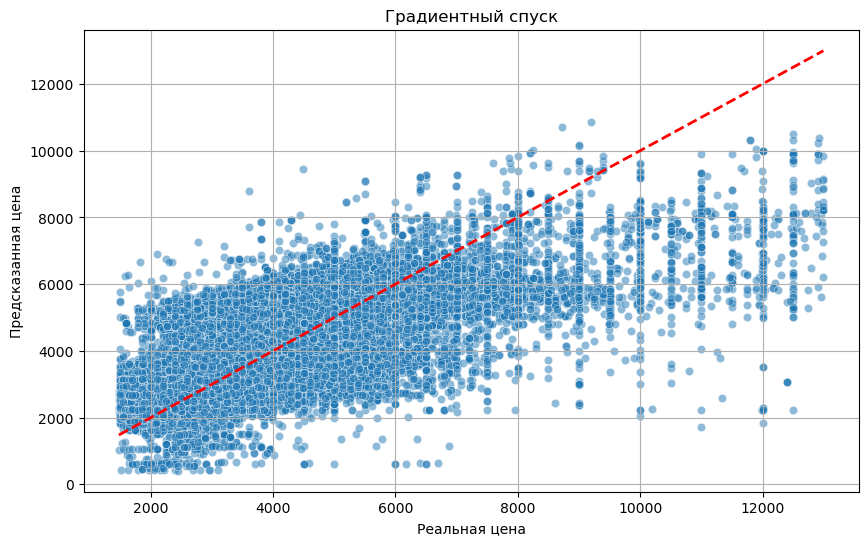

In [61]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red', lw=2)
plt.xlabel("Реальная цена")
plt.ylabel("Предсказанная цена")
plt.title("Градиентный спуск")
plt.grid(True)
plt.show()

#### Обучение с использованием модели sklearn.LinearRegression

In [62]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sklearn_model = LinearRegression()
sklearn_model.fit(X_train, y_train)

y_train_pred = sklearn_model.predict(X_train)
y_test_pred = sklearn_model.predict(X_test)

add_result('LinReg sklearn', y_train, y_train_pred, y_test, y_test_pred)

print("\nМетрики для sklearn:\n")
print(f"Train:")
print(f"  MAE  = {mean_absolute_error(y_train, y_train_pred):.2f}")
print(f"  RMSE = {mean_squared_error(y_train, y_train_pred):.2f}")
print(f"  R²   = {r2_score(y_train, y_train_pred):.4f}\n")

print(f"Test:")
print(f"  MAE  = {mean_absolute_error(y_test, y_test_pred):.2f}")
print(f"  RMSE = {mean_squared_error(y_test, y_test_pred):.2f}")
print(f"  R²   = {r2_score(y_test, y_test_pred):.4f}")


Метрики для sklearn:

Train:
  MAE  = 707.38
  RMSE = 1047145.33
  R²   = 0.5910

Test:
  MAE  = 711.54
  RMSE = 1042879.77
  R²   = 0.5788


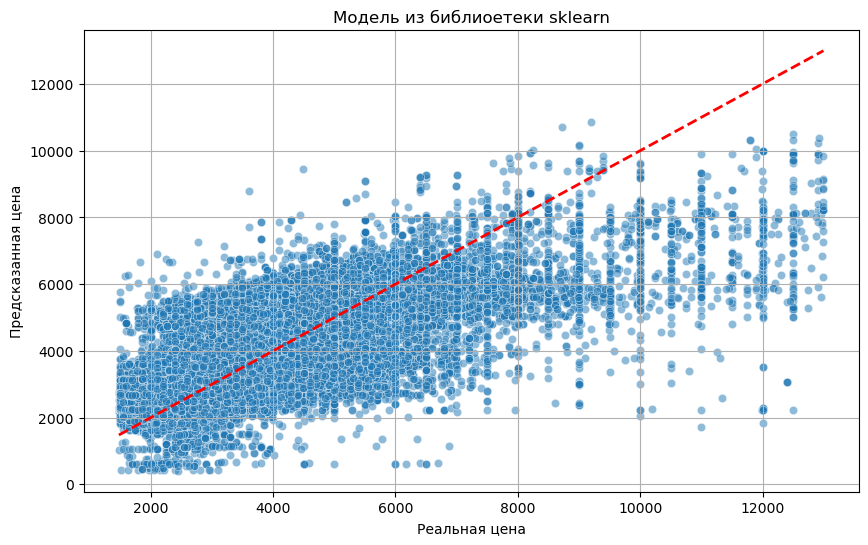

In [63]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red', lw=2)
plt.xlabel("Реальная цена")
plt.ylabel("Предсказанная цена")
plt.title("Модель из библиоетеки sklearn")
plt.grid(True)
plt.show()

In [64]:
print(f"      MAE \n {result_MAE}" )
print(f"\n      RMSE \n {result_RMSE}" )
print(f"\n      R2 \n {result_R2}" )

      MAE 
                model       train        test
0  LinReg Analytical  707.380082  711.544373
1          LinReg GD  707.368113  711.522471
2     LinReg sklearn  707.380082  711.544373

      RMSE 
                model        train         test
0  LinReg Analytical  1023.301192  1021.214852
1          LinReg GD  1023.307804  1021.209719
2     LinReg sklearn  1023.301192  1021.214852

      R2 
                model     train      test
0  LinReg Analytical  0.590966  0.578827
1          LinReg GD  0.590960  0.578831
2     LinReg sklearn  0.590966  0.578827


#### Ridge (L2)

In [65]:
class MyRidgeRegression:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.w = None

    def fit(self, X, y):
        Xb = np.hstack([np.ones((X.shape[0], 1)), X])
        I = np.eye(Xb.shape[1])
        I[0, 0] = 0
        self.w = np.linalg.inv(Xb.T @ Xb + self.alpha * I) @ Xb.T @ y

    def predict(self, X):
        Xb = np.hstack([np.ones((X.shape[0], 1)), X])
        return Xb @ self.w

#### Lasso (L1)

In [66]:
class MyLassoRegression:
    def __init__(self, lr=0.01, n_epochs=1000, alpha=0.1):
        self.lr = lr
        self.n_epochs = n_epochs
        self.alpha = alpha
        self.w = None
        self.b = 0

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)

        for _ in range(self.n_epochs):
            y_pred = np.dot(X, self.w) + self.b
            error = y_pred - y

            dw = (X.T @ error) / n_samples + self.alpha * np.sign(self.w)
            db = np.mean(error)

            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.w) + self.b

#### ElasticNet

In [67]:
class MyElasticNet:
    def __init__(self, lr=0.01, n_epochs=1000, alpha1=0.1, alpha2=0.1):
        self.lr = lr
        self.n_epochs = n_epochs
        self.alpha1 = alpha1
        self.alpha2 = alpha2
        self.w = None
        self.b = 0

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)

        for _ in range(self.n_epochs):
            y_pred = np.dot(X, self.w) + self.b
            error = y_pred - y

            dw = (2 * (X.T @ error)) / n_samples + self.alpha1 * np.sign(self.w) + 2 * self.alpha2 * self.w
            db = np.mean(error)

            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.w) + self.b

#### Обучение

In [68]:
ridge_model = MyRidgeRegression(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_train_pred = ridge_model.predict(X_train)
y_test_pred  = ridge_model.predict(X_test)
add_result('My Ridge', y_train, y_train_pred, y_test, y_test_pred)

In [69]:
lasso_model = MyLassoRegression(lr=0.01, n_epochs=3000, alpha=0.01)
lasso_model.fit(X_train, y_train)
y_train_pred = lasso_model.predict(X_train)
y_test_pred  = lasso_model.predict(X_test)
add_result('My Lasso', y_train, y_train_pred, y_test, y_test_pred)

In [70]:
en_model = MyElasticNet(lr=0.01, n_epochs=3000, alpha1=0.01, alpha2=0.01)
en_model.fit(X_train, y_train)
y_train_pred = en_model.predict(X_train)
y_test_pred  = en_model.predict(X_test)
add_result('My ElasticNet', y_train, y_train_pred, y_test, y_test_pred)

In [71]:
print(f"      MAE \n {result_MAE}" )
print(f"\n      RMSE \n {result_RMSE}" )
print(f"\n      R2 \n {result_R2}" )

      MAE 
                model       train        test
0  LinReg Analytical  707.380082  711.544373
1          LinReg GD  707.368113  711.522471
2     LinReg sklearn  707.380082  711.544373
3           My Ridge  707.376587  711.540189
4           My Lasso  707.423753  711.551690
5      My ElasticNet  706.372584  710.010959

      RMSE 
                model        train         test
0  LinReg Analytical  1023.301192  1021.214852
1          LinReg GD  1023.307804  1021.209719
2     LinReg sklearn  1023.301192  1021.214852
3           My Ridge  1023.301198  1021.213625
4           My Lasso  1023.781210  1021.506173
5      My ElasticNet  1024.247964  1021.497242

      R2 
                model     train      test
0  LinReg Analytical  0.590966  0.578827
1          LinReg GD  0.590960  0.578831
2     LinReg sklearn  0.590966  0.578827
3           My Ridge  0.590966  0.578828
4           My Lasso  0.590582  0.578587
5      My ElasticNet  0.590208  0.578594


#### MinMaxScaler

In [72]:
class MyMinMaxScaler:
    def __init__(self):
        self.min_ = None
        self.max_ = None

    def fit(self, X):
        self.min_ = X.min(axis=0)
        self.max_ = X.max(axis=0)
        return self

    def transform(self, X):
        return (X - self.min_) / (self.max_ - self.min_ + 1e-8)

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

#### StandardScaler

In [73]:
class MyStandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        return self

    def transform(self, X):
        return (X - self.mean_) / (self.std_ + 1e-8)

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

#### Сравнение с sklearn

In [74]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

                                # мой MinMaxScaler
my_mm = MyMinMaxScaler()
X_my_mm = my_mm.fit_transform(X_train)

                                # sklearn MinMaxScaler 
sk_mm = MinMaxScaler()
X_sk_mm = sk_mm.fit_transform(X_train)

diff_mm = np.abs(X_my_mm - X_sk_mm).mean()
print(f"Средняя разница между моим и sklearn MinMaxScaler: {diff_mm:.6f}")

                                # мой StandardScaler
my_ss = MyStandardScaler()
X_my_ss = my_ss.fit_transform(X_train)

                                # sklearn StandardScaler 
sk_ss = StandardScaler()
X_sk_ss = sk_ss.fit_transform(X_train)

diff_ss = np.abs(X_my_ss - X_sk_ss).mean()
print(f"Средняя разница между моим и sklearn StandardScaler: {diff_ss:.6f}")

Средняя разница между моим и sklearn MinMaxScaler: 0.000000
Средняя разница между моим и sklearn StandardScaler: 0.000000


#### Обучение на моих реализациях StandardScaler и MinMaxScaler

In [75]:

scaler_minmax = MyMinMaxScaler()
scaler_minmax.fit(X_train)

X_train_minmax = scaler_minmax.transform(X_train)
X_test_minmax = scaler_minmax.transform(X_test)

model_lin_minmax = MyLinearRegressionAnalytical()
model_lin_minmax.fit(X_train_minmax, y_train)
y_train_pred_lin = model_lin_minmax.predict(X_train_minmax)
y_test_pred_lin  = model_lin_minmax.predict(X_test_minmax)

add_result("Linear MinMaxScaler", y_train, y_train_pred_lin, y_test, y_test_pred_lin)

model_ridge_minmax = MyRidgeRegression(alpha=0.1)
model_ridge_minmax.fit(X_train_minmax, y_train)
y_train_pred_ridge = model_ridge_minmax.predict(X_train_minmax)
y_test_pred_ridge  = model_ridge_minmax.predict(X_test_minmax)

add_result("Ridge MinMaxScaler", y_train, y_train_pred_ridge, y_test, y_test_pred_ridge)

model_lasso_minmax = MyLassoRegression(alpha=0.1)
model_lasso_minmax.fit(X_train_minmax, y_train)
y_train_pred_lasso = model_lasso_minmax.predict(X_train_minmax)
y_test_pred_lasso  = model_lasso_minmax.predict(X_test_minmax)

add_result("Lasso MinMaxScaler", y_train, y_train_pred_lasso, y_test, y_test_pred_lasso)

model_en_minmax = MyElasticNet(alpha1=0.1, alpha2=0.1)
model_en_minmax.fit(X_train_minmax, y_train)
y_train_pred_en = model_en_minmax.predict(X_train_minmax)
y_test_pred_en  = model_en_minmax.predict(X_test_minmax)

add_result("ElasticNet MinMaxScaler", y_train, y_train_pred_en, y_test, y_test_pred_en)

In [76]:

scaler = MyStandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_lin_std = MyLinearRegressionAnalytical()
model_lin_std.fit(X_train_scaled, y_train)
y_train_pred_lin = model_lin_std.predict(X_train_scaled)
y_test_pred_lin  = model_lin_std.predict(X_test_scaled)
add_result("Linear StandardScaler", y_train, y_train_pred_lin, y_test, y_test_pred_lin)

model_gd = MyLinearRegressionGD(lr=0.01, n_epochs=1000) 
model_gd.fit(X_train_scaled, y_train)
y_pred_train = model_gd.predict(X_train_scaled)
y_pred_test = model_gd.predict(X_test_scaled)

model_ridge_std = MyRidgeRegression(alpha=0.1)
model_ridge_std.fit(X_train_scaled, y_train)
y_train_pred_ridge = model_ridge_std.predict(X_train_scaled)
y_test_pred_ridge  = model_ridge_std.predict(X_test_scaled)
add_result("Ridge StandardScaler", y_train, y_train_pred_ridge, y_test, y_test_pred_ridge)

model_lasso_std = MyLassoRegression(alpha=0.1)
model_lasso_std.fit(X_train_scaled, y_train)
y_train_pred_lasso = model_lasso_std.predict(X_train_scaled)
y_test_pred_lasso  = model_lasso_std.predict(X_test_scaled)
add_result("Lasso StandardScaler", y_train, y_train_pred_lasso, y_test, y_test_pred_lasso)

model_en_std = MyElasticNet(alpha1=0.1, alpha2=0.1)
model_en_std.fit(X_train_scaled, y_train)
y_train_pred_en = model_en_std.predict(X_train_scaled)
y_test_pred_en  = model_en_std.predict(X_test_scaled)
add_result("ElasticNet StandardScaler", y_train, y_train_pred_en, y_test, y_test_pred_en)

Итерация     1/1000: MSE = 15392404.694498, Δw = 7.995193e+01
Итерация     2/1000: MSE = 14762160.321288, Δw = 7.772464e+01
Итерация     3/1000: MSE = 14166238.026683, Δw = 7.563494e+01
Итерация     4/1000: MSE = 13601677.626779, Δw = 7.366565e+01
Итерация     5/1000: MSE = 13065925.562428, Δw = 7.180210e+01

Последние 5 итераций:
Итерация   996/1000: MSE = 1047180.434155, Δw = 3.047267e-02
Итерация   997/1000: MSE = 1047180.341358, Δw = 3.043226e-02
Итерация   998/1000: MSE = 1047180.248807, Δw = 3.039191e-02
Итерация   999/1000: MSE = 1047180.156502, Δw = 3.035162e-02
Итерация  1000/1000: MSE = 1047180.064441, Δw = 3.031138e-02

 Обучение завершено.
Финальная MSE: 1047179.972624
Итераций выполнено: 1000


#### Переобучение с polynomial_features

In [77]:
def polynomial_features(X, degree=2):

    n_samples, n_features = X.shape
    
    def get_combinations():
        for d in range(degree + 1):
            for combo in itertools.combinations_with_replacement(range(n_features), d):
                yield combo

    combinations = list(get_combinations())
    
    n_output_features = len(combinations)
    X_poly = np.empty((n_samples, n_output_features), dtype=X.dtype)
    
    for i, combo in enumerate(combinations):
        
        X_poly[:, i] = np.prod(X[:, combo], axis=1)
        
    return X_poly

In [78]:
base_features = ['bathrooms', 'bedrooms']

X_train = df_train[base_features].values
y_train = df_train['price'].values

X_test = df_test[base_features].values
y_test = df_test['price'].values

degree = 10

X_train_poly = polynomial_features(X_train, degree=degree)
X_test_poly = polynomial_features(X_test, degree=degree)

scaler = MyStandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled  = scaler.transform(X_test_poly)

In [79]:
model_lin_poly = MyLinearRegressionAnalytical()
model_lin_poly.fit(X_train_poly_scaled, y_train)
y_train_pred_lin_poly = model_lin_poly.predict(X_train_poly_scaled)
y_test_pred_lin_poly  = model_lin_poly.predict(X_test_poly_scaled)
add_result("Linear Polynomial", y_train, y_train_pred_lin_poly, y_test, y_test_pred_lin_poly)

model_ridge_poly = MyRidgeRegression(alpha=0.1)
model_ridge_poly.fit(X_train_poly_scaled, y_train)
y_train_pred_ridge_poly = model_ridge_poly.predict(X_train_poly_scaled)
y_test_pred_ridge_poly  = model_ridge_poly.predict(X_test_poly_scaled)
add_result("Ridge Polynomial", y_train, y_train_pred_ridge_poly, y_test, y_test_pred_ridge_poly)

model_lasso_poly = MyLassoRegression(alpha=1.0)
model_lasso_poly.fit(X_train_poly_scaled, y_train)
y_train_pred_lasso_poly = model_lasso_poly.predict(X_train_poly_scaled)
y_test_pred_lasso_poly  = model_lasso_poly.predict(X_test_poly_scaled)
add_result("Lasso Polynomial", y_train, y_train_pred_lasso_poly, y_test, y_test_pred_lasso_poly)

model_en_poly = MyElasticNet(lr=0.01, n_epochs=4000, alpha1=1.0, alpha2=1.0)
model_en_poly.fit(X_train_poly_scaled, y_train)
y_train_pred_en_poly = model_en_poly.predict(X_train_poly_scaled)
y_test_pred_en_poly  = model_en_poly.predict(X_test_poly_scaled)
add_result("ElasticNet Polynomial", y_train, y_train_pred_en_poly, y_test, y_test_pred_en_poly)

#### Наивные модели

In [80]:
train_mean = np.mean(y_train)
test_mean = np.mean(y_test)

train_median = np.median(y_train)
test_median = np.median(y_test)

y_train_pred_mean = np.full_like(y_train, train_mean)
y_test_pred_mean  = np.full_like(y_test, train_mean)

y_train_pred_median = np.full_like(y_train, train_median)
y_test_pred_median  = np.full_like(y_test, train_median)

add_result("Naive Mean", y_train, y_train_pred_mean, y_test, y_test_pred_mean)
add_result("Naive Median", y_train, y_train_pred_median, y_test, y_test_pred_median)

In [81]:
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

model_gd_log = MyLinearRegressionGD(lr=0.005, n_epochs=10000, eps=0.00001, verbose=True)
model_gd_log.fit(X_train, y_train_log)

y_train_pred_log = model_gd_log.predict(X_train)
y_test_pred_log  = model_gd_log.predict(X_test)

low = np.percentile(y_train_log, 1)
high = np.percentile(y_train_log, 99)
y_train_pred_log_clipped = np.clip(y_train_pred_log, low-1, high+1)
y_test_pred_log_clipped  = np.clip(y_test_pred_log,  low-1, high+1)
y_train_pred = np.expm1(y_train_pred_log_clipped)
y_test_pred  = np.expm1(y_test_pred_log_clipped)

print("y_train_log range:", y_train_log.min(), y_train_log.max())
print("y_train_pred_log range:", y_train_pred_log.min(), y_train_pred_log.max())
print("y_test_log range:", y_test_log.min(), y_test_log.max())
print("y_test_pred_log range:", y_test_pred_log.min(), y_test_pred_log.max())

add_result("LinReg GD + log(y)", y_train, y_train_pred, y_test, y_test_pred)

Итерация     1/10000: MSE =    65.834884, Δw = 1.799622e-01
Итерация     2/10000: MSE =    59.541499, Δw = 1.697465e-01
Итерация     3/10000: MSE =    53.942150, Δw = 1.601219e-01
Итерация     4/10000: MSE =    48.959576, Δw = 1.510550e-01
Итерация     5/10000: MSE =    44.525119, Δw = 1.425140e-01

Сходимость достигнута на итерации 7869: |Δw| = 1.00e-05 < eps = 1e-05

Последние 5 итераций перед остановкой:
Итерация  7865/10000: MSE =     0.076446, Δw = 1.002876e-05
Итерация  7866/10000: MSE =     0.076446, Δw = 1.002112e-05
Итерация  7867/10000: MSE =     0.076446, Δw = 1.001349e-05
Итерация  7868/10000: MSE =     0.076446, Δw = 1.000585e-05
Итерация  7869/10000: MSE =     0.076446, Δw = 9.998230e-06

 Обучение завершено.
Финальная MSE: 0.076446
Итераций выполнено: 7869
y_train_log range: 7.303843225277705 9.472396896788991
y_train_pred_log range: 7.4646329533825035 9.94035481168648
y_test_log range: 7.300472814267799 9.472396896788991
y_test_pred_log range: 7.4646329533825035 9.69882

In [82]:
result_MAE


,model,train,test
0,LinReg Analytical,707.380082,711.544373
1,LinReg GD,707.368113,711.522471
2,LinReg sklearn,707.380082,711.544373
3,My Ridge,707.376587,711.540189
4,My Lasso,707.423753,711.551690
5,My ElasticNet,706.372584,710.010959
6,Linear MinMaxScaler,707.380082,711.544373
7,Ridge MinMaxScaler,707.379658,711.542811
8,Lasso MinMaxScaler,898.761315,884.717018
9,ElasticNet MinMaxScaler,925.301370,911.177689


In [83]:
result_RMSE

,model,train,test
0,LinReg Analytical,1023.301192,1021.214852
1,LinReg GD,1023.307804,1021.209719
2,LinReg sklearn,1023.301192,1021.214852
3,My Ridge,1023.301198,1021.213625
4,My Lasso,1023.781210,1021.506173
5,My ElasticNet,1024.247964,1021.497242
6,Linear MinMaxScaler,1023.301192,1021.214852
7,Ridge MinMaxScaler,1023.301201,1021.212808
8,Lasso MinMaxScaler,1289.429816,1265.729000
9,ElasticNet MinMaxScaler,1335.704083,1309.579751


In [84]:
result_R2

,model,train,test
0,LinReg Analytical,5.909657e-01,0.578827
1,LinReg GD,5.909604e-01,0.578831
2,LinReg sklearn,5.909657e-01,0.578827
3,My Ridge,5.909657e-01,0.578828
4,My Lasso,5.905818e-01,0.578587
5,My ElasticNet,5.902084e-01,0.578594
6,Linear MinMaxScaler,5.909657e-01,0.578827
7,Ridge MinMaxScaler,5.909657e-01,0.578829
8,Lasso MinMaxScaler,3.505463e-01,0.352995
9,ElasticNet MinMaxScaler,3.030954e-01,0.307388
